# Opciones adicionales sobre gráficos

Crea un programa MultiplesGraficos.py con un panel 2x2 para mostrar 4 gráficos diferentes sobre el dataset que se te proporcionará sobre parques eólicos de Castilla y León.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos
parques_eolicos_df = pd.read_csv("parques_eolicos.csv", sep=';')
parques_eolicos_df.head()

,num,nombre,municipio,provincia,potencia,tecnologia,aerogeneradores,potencia_unitaria
0,225.0,Aerogenerador Experimental I+D G-87,Lubián,ZA,2000,GAMESA,1,2000
1,226.0,Aerogenerador Experimental I+D G-90,Lubián,ZA,2000,GAMESA,1,2000
2,162.0,Ágreda,Agreda,SO,18000,ACCIONA,12,1500
3,153.0,ALBA DE TORMES,Alba de Tormes,SA,4500,MTORRES,3,1500
4,108.0,Alconada,Ampudia,PA,4500,ACCIONA,3,1500


En concreto, se piden los siguientes gráficos:
- Gráfico circular que muestre la proporción de parques eólicos por provincia.
- Gráfico de barras con la potencia media por provincia.
- Histograma con la frecuencia del número de aerogeneradores.
- Gráfico de cajas que muestre la dispersión del número de aerogeneradores en Valladolid y Palencia.

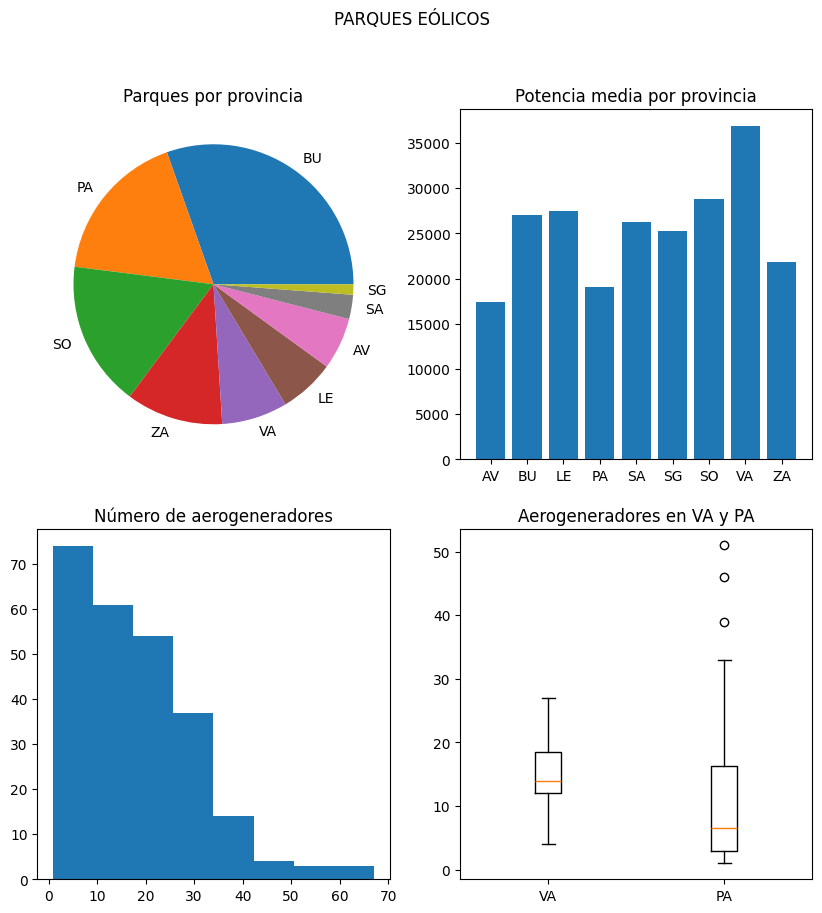

In [43]:
# Malla de gráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

# Gráfico circular que muestre la proporción de parques eólicos por provincia
parques_eolicos_por_provincia = parques_eolicos_df['provincia'].value_counts()

axes[0, 0].pie(
    parques_eolicos_por_provincia.values,
    labels=parques_eolicos_por_provincia.index
)
axes[0, 0].set_title('Parques por provincia')

# Gráfico de barras con la potencia media por provincia
potencia_media_por_provincia = (parques_eolicos_df.groupby('provincia')['potencia'].mean())

axes[0, 1].bar(
    potencia_media_por_provincia.index,
    potencia_media_por_provincia.values,
    align='center'
)
axes[0, 1].set_title('Potencia media por provincia')

# Histograma con la frecuencia del número de aerogeneradores
axes[1, 0].hist(parques_eolicos_df['aerogeneradores'], bins=8)
axes[1, 0].set_title('Número de aerogeneradores')

# Gráfico de cajas que muestre la dispersión del número de aerogeneradores en Valladolid y Palencia
filtrado_provincias = ['VA', 'PA']

df_filtrado_provincias = parques_eolicos_df[
    parques_eolicos_df['provincia'].isin(filtrado_provincias)
]

datos_boxplot = [
    df_filtrado_provincias[df_filtrado_provincias['provincia'] == prov]['aerogeneradores']
    for prov in filtrado_provincias
]

axes[1, 1].boxplot(datos_boxplot, tick_labels=['VA', 'PA'])
axes[1, 1].set_title('Aerogeneradores en VA y PA')

# Dibujar gráficas
fig.suptitle('PARQUES EÓLICOS')
plt.show()